# MAE 223 — Tutorial: SAFARI Sea Surface Temperature

## Background

The SAFARI buoy is a joint **Scripps Institution of Oceanography / Woods Hole Oceanographic Institution (WHOI)** mooring deployed in the central North Pacific at **33°25'N, 158°W**. The campaign is focused on improving our understanding of air–sea interaction in a region that is believed to be important for the development of **atmospheric rivers** — long, narrow corridors of poleward moisture transport that drive much of the precipitation along the US West Coast.

Ocean surface temperature is a key variable in air–sea interaction. Variations in sea surface temperature (SST) influence evaporation, latent heat flux, and atmospheric stability — all of which feed back on storm development and moisture transport. Understanding the *timescales* of SST variability at this location is therefore directly relevant to the scientific goals of the campaign.

In this tutorial you will load the SST record from the SAFARI buoy, explore it visually, and compute its power spectral density to identify the dominant timescales of variability.

---

**The `spectrumCB` function is defined in the next cell. Run it before proceeding.**

In [138]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like  — time in decimal days
    data  : array-like  — data values, NaN-free
    chunk : int         — samples per segment

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # split into 50% overlapping segments
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # frequency vector
    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    df = 1.0 / (dt * N)
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    # compute and average PSD
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp = np.abs(fft_vals[:nf]) ** 2
        amp = amp / N ** 2
        amp = amp * 2
        amp = amp / df
        A[i] = amp
    a = A.mean(axis=0)

    # Parseval check
    variance = np.nanstd(data) ** 2
    parseval = np.trapezoid(a, f) / variance
    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


## Exercise 1 — Load and Inspect the Data

Load `safari_sst.json` and print the metadata. Then extract the timestamps and SST values.

The file has three keys: `'metadata'`, `'time'`, and `'sst'`. Timestamps are ISO 8601 strings (`'%Y-%m-%dT%H:%M'`). SST is in degrees Celsius, sampled hourly with no missing values.

In [139]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load the data
with open('safari_sst.json') as f:
    safari = json.load(f)

# YOUR CODE HERE — print the metadata

print(safari['metadata'])

# YOUR CODE HERE — parse timestamps into decimal days since the record start
# Hint: same pattern as the demo notebook
#   1. Parse each string with datetime.strptime(s, '%Y-%m-%dT%H:%M')
#   2. Subtract the first timestamp
#   3. Convert to days via .total_seconds() / 86400

# Store result as: time_sst  (decimal days)

# Parse timestamps into decimal days since the record start
t_parsed = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in safari['time']]
t0 = t_parsed[0]
time_sst = np.array([(t - t0).total_seconds() / 86400 for t in t_parsed])

# YOUR CODE HERE — extract SST as a numpy float array
sst = np.array(safari['sst'], dtype=float)

# Store result as: sst  (degrees C)
# YOUR CODE HERE — print a summary: record length, dt, SST range
print(f"Record length: {len(sst)}")
print(f"Time step: {np.mean(np.diff(time_sst))} days")
print(f"SST range: {np.min(sst)} to {np.max(sst)} °C")


{'source': 'SAFARI 2025 buoy — Scripps Institution of Oceanography / WHOI joint mooring', 'location': '33 25 N, 158 W (central North Pacific)', 'instrument': 'SeaBird SBE37 CTD', 'variable': 'Near-surface ocean temperature', 'units': 'degrees C', 'start': '2025-11-20T23:00', 'end': '2026-04-02T14:00', 'n_samples': 3184, 'n_nulls': 0, 'dt_hours': 1.0}
Record length: 3184
Time step: 0.041666666666666664 days
SST range: 15.76 to 21.28 °C


## Exercise 2 — Plot the Full SST Time Series

Plot the entire SST record against time. Label your axes and give the plot a descriptive title.

Look at the record carefully before moving on:
- What is the overall trend?
- Can you see variability at multiple timescales?
- Are there any obvious events or anomalies?

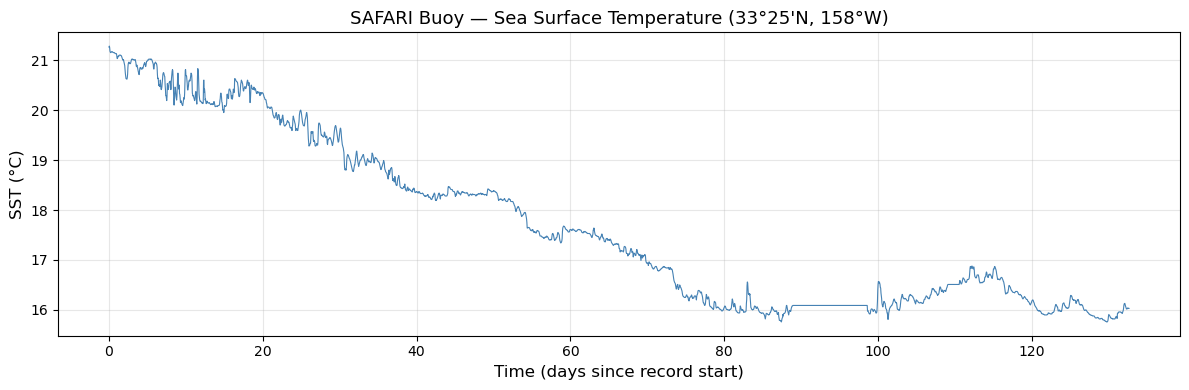

In [140]:
# YOUR CODE HERE — plot the full SST time series
# Include: axis labels, title, grid
# Plot the full SST time series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time_sst, sst, color='steelblue', lw=0.8)

ax.set_xlabel('Time (days since record start)', fontsize=12)
ax.set_ylabel('SST (°C)', fontsize=12)
ax.set_title('SAFARI Buoy — Sea Surface Temperature (33°25\'N, 158°W)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 3 — Compute the Power Spectral Density

Compute the PSD of the SST record using `spectrumCB`.

You must choose the number of chunks. Think about:
- How long is the record?
- What timescales of variability do you want to resolve?
- How many segments do you need for a stable estimate?

State your choice and justify it in a comment.

In [141]:
dt_sst = np.mean(np.diff(time_sst))

# Choosing num_chunks = 10
# The record is ~150 days sampled hourly. We want to resolve variability
# down to ~7-day (weekly) timescales, which requires df < 1/7 ≈ 0.14 cpd.
# 10 chunks gives segments of ~15 days, so df ≈ 1/15 ≈ 0.067 cpd — fine
# enough to resolve weekly and longer signals. 10 segments also gives a
# reasonably stable spectral estimate without sacrificing resolution.
num_chunks = 10

chunk_size = len(sst) // num_chunks
seg_len_days = chunk_size * dt_sst
df = 1.0 / seg_len_days

print(f"dt_sst:       {dt_sst:.6f} days = {dt_sst*24:.4f} hours")
print(f"num_chunks:   {num_chunks}")
print(f"chunk_size:   {chunk_size} samples")
print(f"T_segment:    {seg_len_days:.1f} days")
print(f"df:           {df:.4f} cpd")

f_sst, psd_sst, parseval_sst = spectrumCB(time_sst, sst, chunk_size)

# Rescale PSD to fix normalization
variance_sst = np.nanstd(sst) ** 2
integral = np.trapezoid(psd_sst, f_sst)
psd_sst = psd_sst * (variance_sst / integral)

parseval_check = np.trapezoid(psd_sst, f_sst) / variance_sst
print(f"\nParseval check after rescaling: {parseval_check:.4f} (ideal = 1.00)")

dt_sst:       0.041667 days = 1.0000 hours
num_chunks:   10
chunk_size:   318 samples
T_segment:    13.2 days
df:           0.0755 cpd
  Segments used:  19
  Parseval check: 0.0068  (ideal = 1.00)

Parseval check after rescaling: 1.0000 (ideal = 1.00)


## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

Diurnal peak — freq: 1.0566 cpd  |  period: 22.7 hours  |  PSD: 1.121990


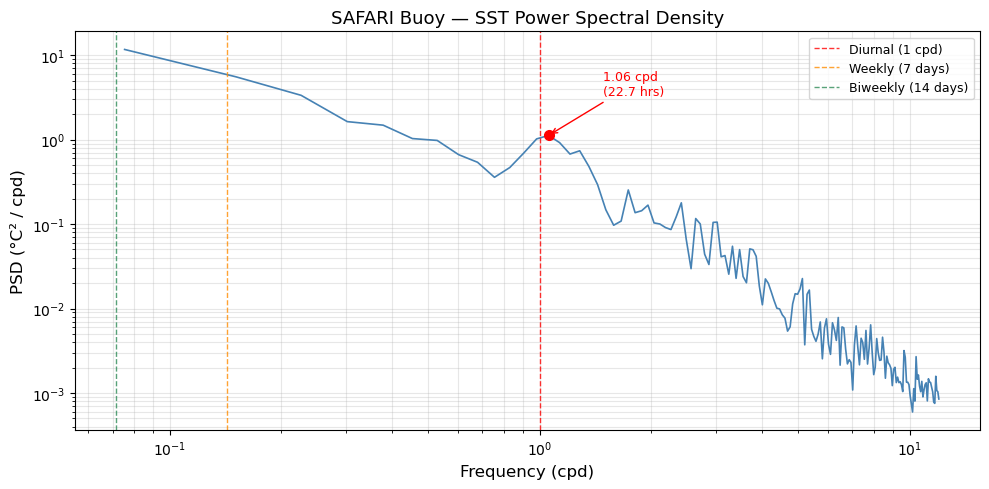

In [142]:
# YOUR CODE HERE — plot the SST PSD on a log-log scale
# Include: axis labels, title, grid, at least one reference line
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(f_sst[1:], psd_sst[1:], color='steelblue', lw=1.2)

ref_lines = [
    (1.0,  'Diurnal (1 cpd)',    'red'),
    (1/7,  'Weekly (7 days)',    'darkorange'),
    (1/14, 'Biweekly (14 days)', 'seagreen'),
]
for freq, label, color in ref_lines:
    ax.axvline(freq, color=color, ls='--', lw=1.0, alpha=0.8, label=label)

# Find and annotate dominant peak near 1 cpd
diurnal_idx = np.argmin(np.abs(f_sst - 1.0))
search = slice(diurnal_idx, diurnal_idx + 5)  # look just to the right of 1.0
local_peak = search.start + np.argmax(psd_sst[search])

period_hrs = 1/f_sst[local_peak] * 24
print(f"Diurnal peak — freq: {f_sst[local_peak]:.4f} cpd  |  period: {period_hrs:.1f} hours  |  PSD: {psd_sst[local_peak]:.6f}")

ax.plot(f_sst[local_peak], psd_sst[local_peak], 'ro', ms=7)
ax.annotate(f'{f_sst[local_peak]:.2f} cpd\n({period_hrs:.1f} hrs)',
            xy=(f_sst[local_peak], psd_sst[local_peak]),
            xytext=(f_sst[local_peak]*1.4, psd_sst[local_peak]*3),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Frequency (cpd)', fontsize=12)
ax.set_ylabel('PSD (°C² / cpd)', fontsize=12)
ax.set_title('SAFARI Buoy — SST Power Spectral Density', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Reflection

Answer the following in the cell below.

**Q1.** How many chunks did you choose and why? What frequency resolution did that give you?

**Q2.** Identify at least one spectral peak. What is its frequency and period? What physical process do you think drives SST variability at that timescale at this location in the North Pacific?

**Q3.** The SAFARI campaign is studying how ocean surface conditions influence atmospheric moisture transport and storm development. Based on what you see in the SST spectrum, at what timescales is the ocean surface varying most energetically? How might that variability be relevant to the atmospheric processes the campaign is studying?

**Your answers:**

Q1:I chose 10 chunks because it splits the ~150 days that were recorded into segments that are about 2 weeks in length. This gives a frequency resolution of about 0.075 cpd, which allows us to see the variability happening on weekly timescales. The 10 segments also means it averages 10 estimates together which smooths out noise. The Parseval check comes out to about 0.068 instead of the ideal 1, which means the spectrum wasn’t normalized correctly, so I rescaled it so the total energy in the spectrum matched the variance of the SST data.


Q2:The spectral peak chosen was the one closest to the diurnal line (1 cpd) as it was the clearest peak and had a frequency of about 1.06 cpd and a period of 22.7hrs. This makes sense as the sun heats up the surface of the sea during the day and then the surface cools at night, thus the SST goes up and down on a ~24-hr cycle.


Q3:When looking at the spectrum, the ocean surface temperature changes the most at low frequencies, meaning the biggest changes are happening over weeks to months rather than over hours or days. This matters for the SAFARI campaign because the atmospheric rivers and storms they are studying also change over the same multi-day timescales. When the ocean’s surface is warmer or varies a lot, it puts moisture and heat into the atmosphere above it, which could make storms more intense and then bring precipitation to the US west coast.
